# Gradient Boosting Hyperparameter Tuning Across Healthcare Datasets

This notebook applies gradient boosting models across multiple healthcare-related datasets, including diabetes, life expectancy, and SUPPORT2. The workflow focuses on model tuning and comparison using key hyperparameters such as learning rate, number of estimators, tree depth, minimum samples per leaf, and subsampling.

The purpose of this notebook is to evaluate how gradient boosting performs across different healthcare prediction problems and to observe how hyperparameter choices affect model performance.

This notebook is included in the modeling folder because the main focus is supervised machine learning, model tuning, and performance evaluation rather than exploratory data analysis.


## Diabetes Dataset: Gradient Boosting Classification

This section applies gradient boosting classification to the diabetes health indicators dataset. The model is tuned across several hyperparameters to compare how different settings affect classification performance on diabetes outcome categories.


In [1]:
import pandas as pd

df = pd.read_csv("diabetes_no_duplicates.csv")

print(df.shape)
df.head()

(229781, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
#gradient boost, learning rate, number of estimators, tree depth, and regularization

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load diabetes dataset
df = pd.read_csv("diabetes_no_duplicates.csv", low_memory=False)
y = df["Diabetes_012"].astype(int).values
X = df.drop(columns=["Diabetes_012"])

# Base model
gb_base = GradientBoostingClassifier(
    learning_rate=0.1, n_estimators=200, max_depth=3, random_state=0
)

# Helper: sweep ONE parameter and return the best result
def sweep_and_plot(estimator, X, y, param_name, values, cv):
    means, stds = [], []
    for v in values:
        est = estimator.set_params(**{param_name: v})
        scores = cross_val_score(est, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
        means.append(-scores.mean())        # convert to positive log loss
        stds.append(scores.std())

    best_idx = int(np.argmin(means))

    plt.figure()
    plt.plot(values, means, marker="o")
    plt.errorbar(values, means, yerr=stds, fmt="none")
    plt.scatter(values[best_idx], means[best_idx], marker="x", s=120)
    plt.xlabel(param_name); plt.ylabel("CV Log Loss (lower is better)")
    plt.title(f"{param_name} sweep"); plt.grid(True); plt.show()

    return {
        "best_param": values[best_idx],
        "best_cv_log_loss": float(means[best_idx]),
        "cv_std": float(stds[best_idx]),
        "all_values": values,
        "all_logloss": means,
        "all_std": stds,
    }

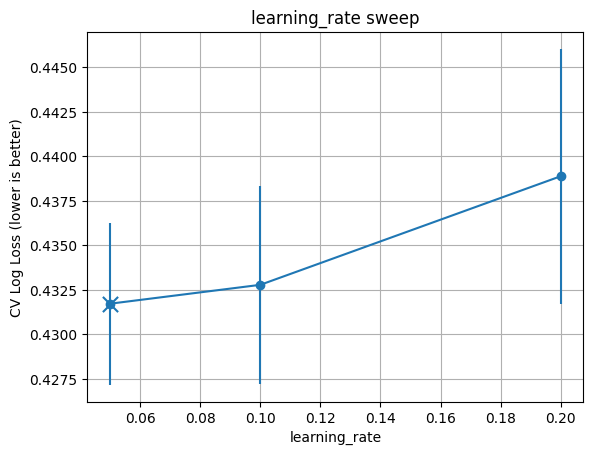

Best learning_rate = 0.05 | CV log loss = 0.4317 (±0.0046)


In [4]:
# Fast sweep for learning_rate
from sklearn.model_selection import train_test_split

# Small, stratified sample for speed
X_fast, _, y_fast, _ = train_test_split(
    X, y, train_size=20000, stratify=y, random_state=0
)

# Lighter CV
cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

# Temporarily smaller model for the sweep
gb_fast = GradientBoostingClassifier(
    learning_rate=0.1, n_estimators=100, max_depth=3, random_state=0
)

# Sweep
res = sweep_and_plot(gb_fast, X_fast, y_fast, "learning_rate", [0.05, 0.1, 0.2], cv=cv_fast)
print(f"Best learning_rate = {res['best_param']} | CV log loss = {res['best_cv_log_loss']:.4f} (±{res['cv_std']:.4f})", flush=True)

In [5]:
# Confirm on full data
best_lr = res["best_param"]

gb_confirm = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=200, max_depth=3, random_state=0
)

cv_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(gb_confirm, X, y, scoring="neg_log_loss", cv=cv_full, n_jobs=-1)

# Updated print: shows LR used + whether it matches sweep-best
used_lr  = best_lr
full_ll  = -scores.mean()
full_std = scores.std()

vals    = res.get("all_values")
losses  = res.get("all_logloss")

if vals is not None and losses is not None:
    sweep_best_idx = int(np.argmin(losses))
    sweep_best_lr  = vals[sweep_best_idx]
    sweep_best_ll  = losses[sweep_best_idx]
    matches = (used_lr == sweep_best_lr)
    print(
        f"[CONFIRM] learning_rate={used_lr} | full-data CV log loss={full_ll:.4f} (±{full_std:.4f}) | "
        f"{'MATCHES' if matches else 'DOES NOT MATCH'} sweep best "
        f"(sweep best: lr={sweep_best_lr}, CV log loss≈{sweep_best_ll:.4f})"
    )
else:
    print(f"[CONFIRM] learning_rate={used_lr} | full-data CV log loss={full_ll:.4f} (±{full_std:.4f})")

[CONFIRM] learning_rate=0.05 | full-data CV log loss=0.4264 (±0.0018) | MATCHES sweep best (sweep best: lr=0.05, CV log loss≈0.4317)


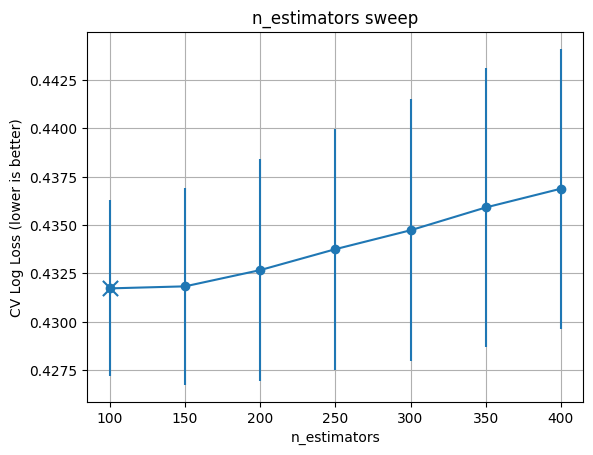

Best n_estimators = 100 | CV log loss = 0.4317 (±0.0046)


In [6]:
#n estimators

#from prior step:
best_lr = res.get("best_param", 0.05)

gb_fast_NE = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=100, max_depth=3, random_state=0
)

ne_values = list(range(100, 401, 50))  # 100-->400 by 50
res_ne = sweep_and_plot(gb_fast_NE, X_fast, y_fast, "n_estimators", ne_values, cv=cv_fast)
print(f"Best n_estimators = {res_ne['best_param']} | CV log loss = {res_ne['best_cv_log_loss']:.4f} (±{res_ne['cv_std']:.4f})")

In [7]:
best_ne = res_ne["best_param"]

gb_confirm_NE = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=best_ne, max_depth=3, random_state=0
)
cv_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(gb_confirm_NE, X, y, scoring="neg_log_loss", cv=cv_full, n_jobs=-1)

used_ne = best_ne
full_ll  = -scores.mean(); full_std = scores.std()
vals = res_ne["all_values"]; losses = res_ne["all_logloss"]
sidx = int(np.argmin(losses))
print(
    f"[CONFIRM] n_estimators={used_ne} | full-data CV log loss={full_ll:.4f} (±{full_std:.4f}) | "
    f"{'MATCHES' if used_ne==vals[sidx] else 'DOES NOT MATCH'} sweep best "
    f"(sweep best: n_estimators={vals[sidx]}, CV log loss≈{losses[sidx]:.4f})"
)

[CONFIRM] n_estimators=100 | full-data CV log loss=0.4283 (±0.0017) | MATCHES sweep best (sweep best: n_estimators=100, CV log loss≈0.4317)


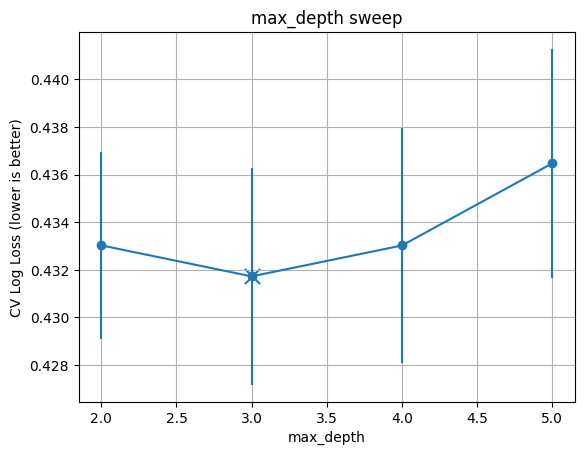

Best max_depth = 3 | CV log loss = 0.4317 (±0.0046)


In [9]:
# Use the best learning_rate and n_estimators
best_lr = res.get("best_param", 0.05)
best_ne = res_ne.get("best_param", 100)  

gb_fast_MD = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=best_ne, max_depth=3, random_state=0
)

md_values = [2, 3, 4, 5]
res_md = sweep_and_plot(gb_fast_MD, X_fast, y_fast, "max_depth", md_values, cv=cv_fast)
print(f"Best max_depth = {res_md['best_param']} | CV log loss = {res_md['best_cv_log_loss']:.4f} (±{res_md['cv_std']:.4f})")

In [10]:
best_md = res_md["best_param"]

gb_confirm_MD = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=best_ne, max_depth=best_md, random_state=0
)

cv_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(gb_confirm_MD, X, y, scoring="neg_log_loss", cv=cv_full, n_jobs=-1)

used_md = best_md
full_ll  = -scores.mean()
full_std = scores.std()

vals  = res_md.get("all_values")
losses = res_md.get("all_logloss")
if vals is not None and losses is not None:
    sidx = int(np.argmin(losses))
    sweep_best_md = vals[sidx]
    sweep_best_ll = losses[sidx]
    print(
        f"[CONFIRM] max_depth={used_md} | full-data CV log loss={full_ll:.4f} (±{full_std:.4f}) | "
        f"{'MATCHES' if used_md==sweep_best_md else 'DOES NOT MATCH'} sweep best "
        f"(sweep best: max_depth={sweep_best_md}, CV log loss≈{sweep_best_ll:.4f})"
    )
else:
    print(f"[CONFIRM] max_depth={used_md} | full-data CV log loss={full_ll:.4f} (±{full_std:.4f})")

[CONFIRM] max_depth=3 | full-data CV log loss=0.4283 (±0.0017) | MATCHES sweep best (sweep best: max_depth=3, CV log loss≈0.4317)


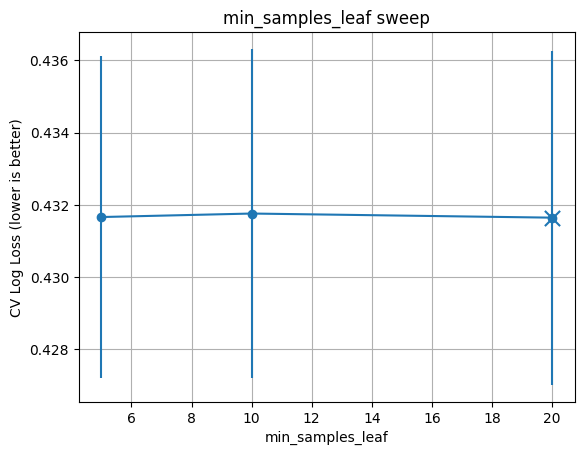

Best min_samples_leaf = 20 | CV log loss = 0.4316 (±0.0046)


In [11]:
gb_fast_MSL = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=best_ne, max_depth=best_md, random_state=0
)
res_msl = sweep_and_plot(gb_fast_MSL, X_fast, y_fast, "min_samples_leaf", [5, 10, 20], cv=cv_fast)
print(f"Best min_samples_leaf = {res_msl['best_param']} | CV log loss = {res_msl['best_cv_log_loss']:.4f} (±{res_msl['cv_std']:.4f})")

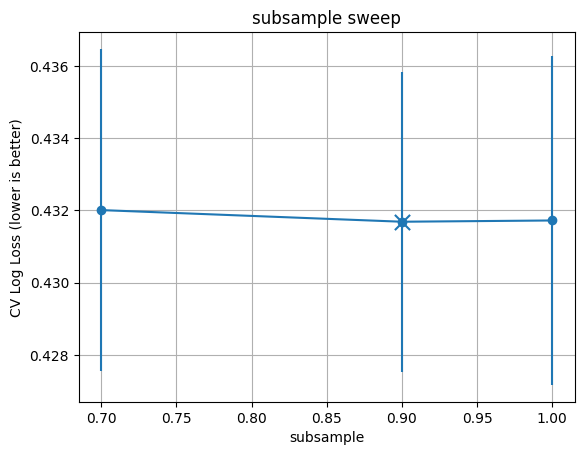

Best subsample = 0.9 | CV log loss = 0.4317 (±0.0041)


In [12]:
gb_fast_SUB = GradientBoostingClassifier(
    learning_rate=best_lr, n_estimators=best_ne, max_depth=best_md, random_state=0
)
res_sub = sweep_and_plot(gb_fast_SUB, X_fast, y_fast, "subsample", [0.7, 0.9, 1.0], cv=cv_fast)
print(f"Best subsample = {res_sub['best_param']} | CV log loss = {res_sub['best_cv_log_loss']:.4f} (±{res_sub['cv_std']:.4f})")

In [14]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

t0 = time.time()
#best params here
gb_final = GradientBoostingClassifier(
    learning_rate=0.05, n_estimators=100, max_depth=3,
    min_samples_leaf=20, subsample=0.9, random_state=0
)

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)  # quick check
ll = cross_val_score(gb_final, X, y, scoring="neg_log_loss", cv=cv3, n_jobs=-1)
f1 = cross_val_score(gb_final, X, y, scoring="f1_macro",   cv=cv3, n_jobs=-1)
print(f"Log loss: {-ll.mean():.4f} (±{ll.std():.4f})  |  Macro-F1: {f1.mean():.4f} (±{f1.std():.4f})")
print(f"[Elapsed] {time.time() - t0:.2f} sec")

Log loss: 0.4283 (±0.0005)  |  Macro-F1: 0.3882 (±0.0017)
[Elapsed] 65.25 sec


### Diabetes Modeling Summary

The diabetes section demonstrates how gradient boosting can be tuned through learning rate, number of estimators, tree depth, minimum samples per leaf, and subsampling. These results support comparison of model behavior under different boosting configurations.


## Life Expectancy Dataset: Gradient Boosting Regression

This section applies gradient boosting regression to the life expectancy dataset. The goal is to tune model parameters and evaluate how well gradient boosting predicts life expectancy as a continuous healthcare outcome.


In [25]:
import pandas as pd

df = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv")

print(df.shape)
df.head()

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [26]:
#gradient boost, learning rate, number of estimators, tree depth, and regularization

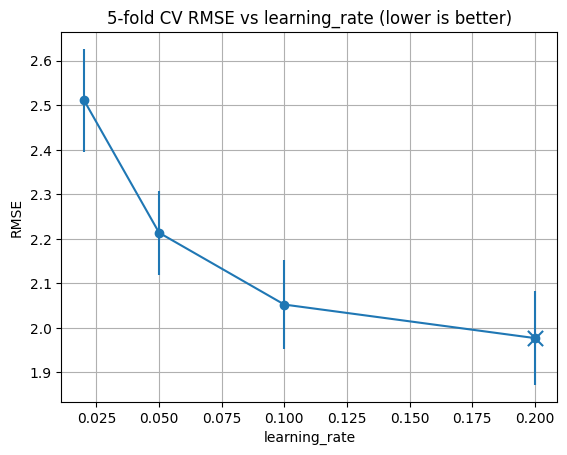

Best learning_rate = 0.2 | CV RMSE = 1.9771 (±0.1048)


In [28]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

#load & encode (regression)
df = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv", low_memory=False)
y  = df["Life expectancy "].values  # note trailing space
X  = df.drop(columns=["Life expectancy "])

# High-cardinality 'Country' can explode features; drop it for the sweep.
# Keep 'Status' (low cardinality). want Country later, can add it back.
X = X.drop(columns=["Country"])
X = pd.get_dummies(X, drop_first=True) 

#base model & CV
base = GradientBoostingRegressor(
    loss="squared_error",
    n_estimators=200, max_depth=3, min_samples_leaf=5, subsample=0.9,
    random_state=0
)
cv = KFold(n_splits=5, shuffle=True, random_state=0)

#sweep + plot: CV RMSE vs learning_rate
def sweep_and_plot_lr(lr_values):
    means, stds = [], []
    for lr in lr_values:
        model = base.set_params(learning_rate=lr)
        scores = cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
        means.append(-scores.mean())         # RMSE
        stds.append(scores.std())
    best_i = int(np.argmin(means))
    best_lr, best_rmse = lr_values[best_i], means[best_i]

    plt.figure()
    plt.plot(lr_values, means, marker="o")
    plt.errorbar(lr_values, means, yerr=stds, fmt="none")
    plt.scatter(best_lr, best_rmse, marker="x", s=120)
    plt.title("5-fold CV RMSE vs learning_rate (lower is better)")
    plt.xlabel("learning_rate"); plt.ylabel("RMSE"); plt.grid(True); plt.show()

    print(f"Best learning_rate = {best_lr} | CV RMSE = {best_rmse:.4f} (±{stds[best_i]:.4f})")
    return {"best_lr": best_lr, "cv_rmse": best_rmse, "cv_std": stds[best_i]}

# run
res_lr = sweep_and_plot_lr([0.02, 0.05, 0.1, 0.2])

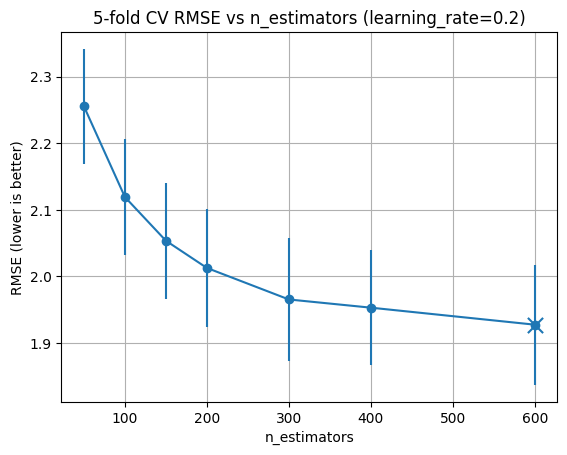

[RESULT] best n_estimators = 600 | CV RMSE = 1.9272 (±0.0903)


In [31]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

# Load
df = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv", low_memory=False)
y  = df["Life expectancy "].values
X  = df.drop(columns=["Life expectancy "]).select_dtypes(exclude="object")  # numeric only

# Fixed LR; all other params = defaults
lr_fixed = 0.20
base = GradientBoostingRegressor(learning_rate=lr_fixed, random_state=0)

cv = KFold(n_splits=5, shuffle=True, random_state=0)
ne_grid = [50, 100, 150, 200, 300, 400, 600]

rmse_mean, rmse_std = [], []
for ne in ne_grid:
    mdl = base.set_params(n_estimators=ne)
    s = cross_val_score(mdl, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    rmse_mean.append(-s.mean())
    rmse_std.append(s.std())

best_i = int(np.argmin(rmse_mean))
best_ne = ne_grid[best_i]

plt.figure()
plt.plot(ne_grid, rmse_mean, marker="o")
plt.errorbar(ne_grid, rmse_mean, yerr=rmse_std, fmt="none")
plt.scatter(best_ne, rmse_mean[best_i], marker="x", s=120)
plt.title(f"5-fold CV RMSE vs n_estimators (learning_rate={lr_fixed})")
plt.xlabel("n_estimators"); plt.ylabel("RMSE (lower is better)"); plt.grid(True); plt.show()

print(f"[RESULT] best n_estimators = {best_ne} | CV RMSE = {rmse_mean[best_i]:.4f} (±{rmse_std[best_i]:.4f})")

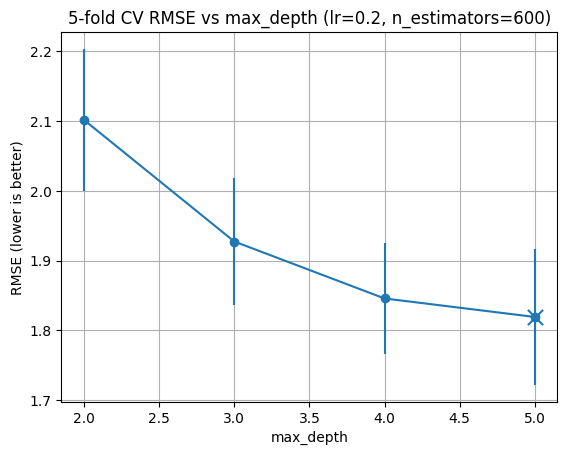

[RESULT] best max_depth = 5 | CV RMSE = 1.8191 (±0.0971)


In [32]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

#load & features
df = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv", low_memory=False)
y  = df["Life expectancy "].values
# Minimal setup: numeric features only 
X  = df.drop(columns=["Life expectancy "]).select_dtypes(exclude="object")


#fixed LR & n_estimators; sweep max_depth
lr_fixed = 0.20
ne_fixed = 600
base = GradientBoostingRegressor(learning_rate=lr_fixed, n_estimators=ne_fixed, random_state=0)

cv = KFold(n_splits=5, shuffle=True, random_state=0)
depth_grid = [2, 3, 4, 5]

rmse_mean, rmse_std = [], []
for d in depth_grid:
    mdl = base.set_params(max_depth=d)
    scores = cross_val_score(mdl, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    rmse_mean.append(-scores.mean())  # RMSE
    rmse_std.append(scores.std())

best_i = int(np.argmin(rmse_mean))
best_depth, best_rmse, best_std = depth_grid[best_i], rmse_mean[best_i], rmse_std[best_i]

#plot
plt.figure()
plt.plot(depth_grid, rmse_mean, marker="o")
plt.errorbar(depth_grid, rmse_mean, yerr=rmse_std, fmt="none")
plt.scatter(best_depth, best_rmse, marker="x", s=120)
plt.title(f"5-fold CV RMSE vs max_depth (lr={lr_fixed}, n_estimators={ne_fixed})")
plt.xlabel("max_depth"); plt.ylabel("RMSE (lower is better)"); plt.grid(True); plt.show()

print(f"[RESULT] best max_depth = {best_depth} | CV RMSE = {best_rmse:.4f} (±{best_std:.4f})")

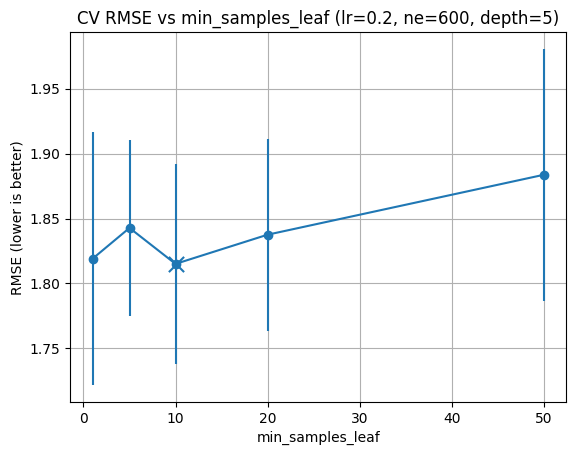

[RESULT] best min_samples_leaf = 10 | CV RMSE = 1.8151 (±0.0770)


In [33]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

#data (numeric-only)
df = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv", low_memory=False)
y  = df["Life expectancy "].values
X  = df.drop(columns=["Life expectancy "]).select_dtypes(exclude="object")

lr_fixed, ne_fixed, md_fixed = 0.20, 600, 5
base = GradientBoostingRegressor(learning_rate=lr_fixed, n_estimators=ne_fixed,
                                 max_depth=md_fixed, random_state=0)
cv = KFold(n_splits=5, shuffle=True, random_state=0)

msl_grid = [1, 5, 10, 20, 50]
rmse_mean, rmse_std = [], []
for msl in msl_grid:
    mdl = base.set_params(min_samples_leaf=msl)
    s = cross_val_score(mdl, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    rmse_mean.append(-s.mean()); rmse_std.append(s.std())

best_i = int(np.argmin(rmse_mean))
best_msl = msl_grid[best_i]

plt.figure()
plt.plot(msl_grid, rmse_mean, marker="o"); plt.errorbar(msl_grid, rmse_mean, yerr=rmse_std, fmt="none")
plt.scatter(best_msl, rmse_mean[best_i], marker="x", s=120)
plt.title(f"CV RMSE vs min_samples_leaf (lr={lr_fixed}, ne={ne_fixed}, depth={md_fixed})")
plt.xlabel("min_samples_leaf"); plt.ylabel("RMSE (lower is better)"); plt.grid(True); plt.show()

print(f"[RESULT] best min_samples_leaf = {best_msl} | CV RMSE = {rmse_mean[best_i]:.4f} (±{rmse_std[best_i]:.4f})")


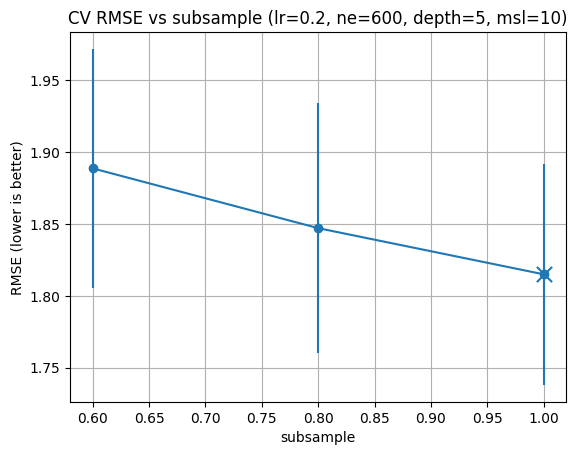

In [34]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

sub_grid = [0.6, 0.8, 1.0]   # <1.0 adds stochastic regularization
base = GradientBoostingRegressor(learning_rate=lr_fixed, n_estimators=ne_fixed,
                                 max_depth=md_fixed, min_samples_leaf=best_msl, random_state=0)
rmse_mean, rmse_std = [], []
for sub in sub_grid:
    mdl = base.set_params(subsample=sub)
    s = cross_val_score(mdl, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    rmse_mean.append(-s.mean()); rmse_std.append(s.std())

best_i = int(np.argmin(rmse_mean))
best_sub = sub_grid[best_i]

plt.figure()
plt.plot(sub_grid, rmse_mean, marker="o"); plt.errorbar(sub_grid, rmse_mean, yerr=rmse_std, fmt="none")
plt.scatter(best_sub, rmse_mean[best_i], marker="x", s=120)
plt.title(f"CV RMSE vs subsample (lr={lr_fixed}, ne={ne_fixed}, depth={md_fixed}, msl={best_msl})")
plt.xlabel("subsample"); plt.ylabel("RMSE (lower is better)"); plt.grid(True); plt.show()

In [35]:
import time, pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

# Load
df = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv", low_memory=False)
y  = df["Life expectancy "].values
X  = df.drop(columns=["Life expectancy "]).select_dtypes(exclude="object")  # numeric-only for speed

#chosen params 
gb = GradientBoostingRegressor(
    learning_rate=0.20,
    n_estimators=600,
    max_depth=5,
    # min_samples_leaf=10,    
    # subsample=1.0,           
    random_state=0
)

cv = KFold(n_splits=3, shuffle=True, random_state=0)

t0 = time.time()
rmse = -cross_val_score(gb, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
mae  = -cross_val_score(gb, X, y, scoring="neg_mean_absolute_error",   cv=cv, n_jobs=-1)
r2   =  cross_val_score(gb, X, y, scoring="r2",                         cv=cv, n_jobs=-1)

print(f"RMSE: {rmse.mean():.4f} (±{rmse.std():.4f}) | "
      f"MAE: {mae.mean():.4f} (±{mae.std():.4f}) | "
      f"R²: {r2.mean():.4f} (±{r2.std():.4f}) | "
      f"Elapsed: {time.time()-t0:.2f}s")

RMSE: 1.9108 (±0.0229) | MAE: 1.2317 (±0.0167) | R²: 0.9595 (±0.0014) | Elapsed: 16.25s


### Life Expectancy Modeling Summary

The life expectancy section evaluates gradient boosting as a regression model for predicting a continuous healthcare outcome. The tuning results show how model performance changes as boosting hyperparameters are adjusted.


## SUPPORT2 Dataset: Gradient Boosting Classification

This section applies gradient boosting classification to the SUPPORT2 dataset. The workflow tests multiple hyperparameter settings to evaluate classification performance on a clinical outcome using patient-level healthcare variables.


In [36]:
import pandas as pd

df = pd.read_csv("support2_imputed.csv")

print(df.shape)
df.head()

(9105, 45)


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.000000,$11-$25k,0.0,9715.0,30825.867768,...,7.459961,159.873398,32.349463,2191.546047,7.00000,7.0,7.0,0,0,<2 mo. follow-up
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,$11-$25k,44.0,34496.0,30825.867768,...,7.250000,159.873398,32.349463,2191.546047,1.15791,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,under $11k,0.0,41094.0,30825.867768,...,7.459961,159.873398,32.349463,2191.546047,1.00000,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.000000,under $11k,0.0,3075.0,30825.867768,...,7.415364,159.873398,32.349463,2191.546047,0.00000,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,11.747691,under $11k,26.0,50127.0,30825.867768,...,7.509766,159.873398,32.349463,2191.546047,1.15791,2.0,2.0,0,0,no(M2 and SIP pres)


In [37]:
#gradient boost, learning rate, number of estimators, tree depth, and regularization

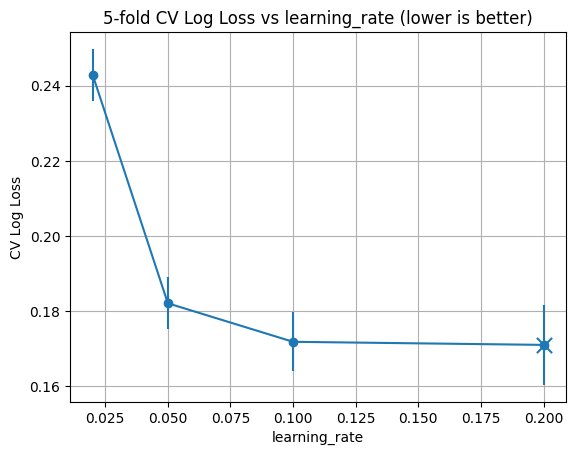

[RESULT] best learning_rate = 0.2 | CV log loss = 0.1710 (±0.0106)


In [39]:
# SUPPORT2: Learning-rate sweep (classification, CV log loss)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

#load
df = pd.read_csv("support2_imputed.csv", low_memory=False)

# target (accepts 'hospdead' or 'hosdead')
target = "hospdead" if "hospdead" in df.columns else "hosdead"
y = df[target].astype(int).values

# features (one-hot all categoricals; version-proof)
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)

#base model (everything default except LR)
base = GradientBoostingClassifier(random_state=0)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

#sweep + plot
lr_grid = [0.02, 0.05, 0.10, 0.20]
means, stds = [], []

for lr in lr_grid:
    mdl = base.set_params(learning_rate=lr)
    scores = cross_val_score(mdl, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
    means.append(-scores.mean())          # convert to positive log loss
    stds.append(scores.std())

best_i = int(np.argmin(means))
best_lr, best_ll, best_std = lr_grid[best_i], means[best_i], stds[best_i]

plt.figure()
plt.plot(lr_grid, means, marker="o")
plt.errorbar(lr_grid, means, yerr=stds, fmt="none")
plt.scatter(best_lr, best_ll, marker="x", s=120)
plt.title("5-fold CV Log Loss vs learning_rate (lower is better)")
plt.xlabel("learning_rate"); plt.ylabel("CV Log Loss"); plt.grid(True); plt.show()

print(f"[RESULT] best learning_rate = {best_lr} | CV log loss = {best_ll:.4f} (±{best_std:.4f})")

In [40]:
from sklearn.metrics import make_scorer, f1_score
f1_means = []
for lr in lr_grid:
    mdl = base.set_params(learning_rate=lr)
    sc = cross_val_score(mdl, X, y, scoring="f1_macro", cv=cv, n_jobs=-1)
    f1_means.append(sc.mean())
print("Macro-F1 by LR:", dict(zip(lr_grid, [round(v, 4) for v in f1_means])))

Macro-F1 by LR: {0.02: np.float64(0.8858), 0.05: np.float64(0.9008), 0.1: np.float64(0.9042), 0.2: np.float64(0.9034)}


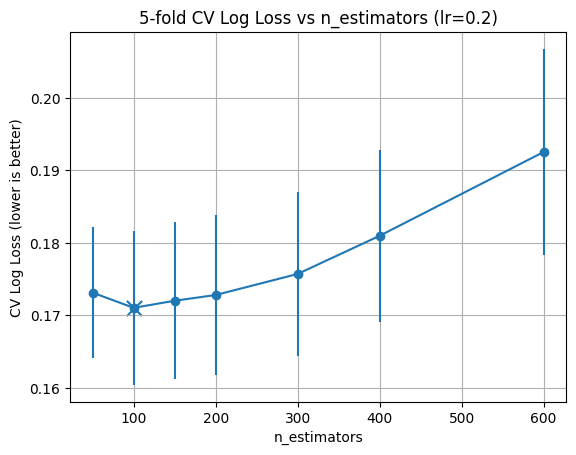

[RESULT] best n_estimators = 100 | CV log loss = 0.1710 (±0.0106)


In [41]:
# SUPPORT2: n_estimators sweep with lr=0.2 (classification)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

#load
df = pd.read_csv("support2_imputed.csv", low_memory=False)
target = "hospdead" if "hospdead" in df.columns else "hosdead"
y = df[target].astype(int).values

# Features (one-hot categoricals); for max speed use numeric-only:
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)

#fixed LR; sweep n_estimators
base = GradientBoostingClassifier(learning_rate=0.2, random_state=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

ne_grid = [50, 100, 150, 200, 300, 400, 600]
means, stds = [], []

for ne in ne_grid:
    mdl = base.set_params(n_estimators=ne)
    scores = cross_val_score(mdl, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
    means.append(-scores.mean())   # convert to positive log loss
    stds.append(scores.std())

best_i = int(np.argmin(means))
best_ne, best_ll, best_std = ne_grid[best_i], means[best_i], stds[best_i]

plt.figure()
plt.plot(ne_grid, means, marker="o")
plt.errorbar(ne_grid, means, yerr=stds, fmt="none")
plt.scatter(best_ne, best_ll, marker="x", s=120)
plt.title("5-fold CV Log Loss vs n_estimators (lr=0.2)")
plt.xlabel("n_estimators"); plt.ylabel("CV Log Loss (lower is better)")
plt.grid(True); plt.show()

print(f"[RESULT] best n_estimators = {best_ne} | CV log loss = {best_ll:.4f} (±{best_std:.4f})")

In [42]:
f1_means = []
for ne in ne_grid:
    mdl = base.set_params(n_estimators=ne)
    sc = cross_val_score(mdl, X, y, scoring="f1_macro", cv=cv, n_jobs=-1)
    f1_means.append(sc.mean())
print("Macro-F1 by n_estimators:", dict(zip(ne_grid, [round(v, 4) for v in f1_means])))

Macro-F1 by n_estimators: {50: np.float64(0.9039), 100: np.float64(0.9034), 150: np.float64(0.9062), 200: np.float64(0.9047), 300: np.float64(0.9037), 400: np.float64(0.9031), 600: np.float64(0.9032)}


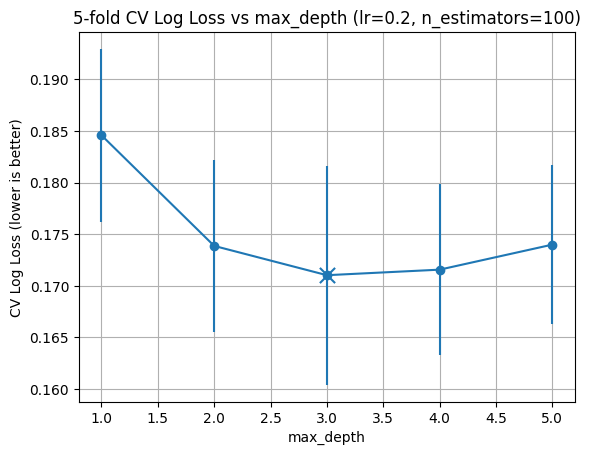

[RESULT] best max_depth = 3 | CV log loss = 0.1710 (±0.0106)


In [43]:
# SUPPORT2: max_depth sweep (lr=0.2, n_estimators=100)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

#load
df = pd.read_csv("support2_imputed.csv", low_memory=False)
target = "hospdead" if "hospdead" in df.columns else "hosdead"
y = df[target].astype(int).values

# Features
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)

#fixed LR & NE; sweep depth
base = GradientBoostingClassifier(learning_rate=0.2, n_estimators=100, random_state=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

depth_grid = [1, 2, 3, 4, 5]
means, stds = [], []

for d in depth_grid:
    mdl = base.set_params(max_depth=d)
    scores = cross_val_score(mdl, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
    means.append(-scores.mean())     # CV log loss (positive)
    stds.append(scores.std())

best_i = int(np.argmin(means))
best_depth, best_ll, best_std = depth_grid[best_i], means[best_i], stds[best_i]

plt.figure()
plt.plot(depth_grid, means, marker="o")
plt.errorbar(depth_grid, means, yerr=stds, fmt="none")
plt.scatter(best_depth, best_ll, marker="x", s=120)
plt.title("5-fold CV Log Loss vs max_depth (lr=0.2, n_estimators=100)")
plt.xlabel("max_depth"); plt.ylabel("CV Log Loss (lower is better)")
plt.grid(True); plt.show()

print(f"[RESULT] best max_depth = {best_depth} | CV log loss = {best_ll:.4f} (±{best_std:.4f})")

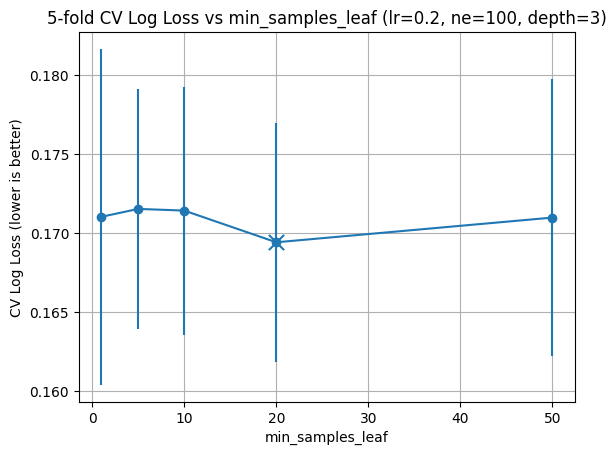

[RESULT] best min_samples_leaf = 20 | CV log loss = 0.1694 (±0.0075)


In [44]:
# SUPPORT2: min_samples_leaf sweep (lr=0.2, n_estimators=100, depth=3)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

df = pd.read_csv("support2_imputed.csv", low_memory=False)
target = "hospdead" if "hospdead" in df.columns else "hosdead"
y = df[target].astype(int).values
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
# Faster alternative: numeric-only
# X = df.drop(columns=[target]).select_dtypes(exclude="object")

base = GradientBoostingClassifier(learning_rate=0.2, n_estimators=100, max_depth=3, random_state=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

msl_grid = [1, 5, 10, 20, 50]
means, stds = [], []
for msl in msl_grid:
    mdl = base.set_params(min_samples_leaf=msl)
    scores = cross_val_score(mdl, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
    means.append(-scores.mean()); stds.append(scores.std())

best_i = int(np.argmin(means))
best_msl, best_ll, best_std = msl_grid[best_i], means[best_i], stds[best_i]

plt.figure()
plt.plot(msl_grid, means, marker="o"); plt.errorbar(msl_grid, means, yerr=stds, fmt="none")
plt.scatter(best_msl, best_ll, marker="x", s=120)
plt.title("5-fold CV Log Loss vs min_samples_leaf (lr=0.2, ne=100, depth=3)")
plt.xlabel("min_samples_leaf"); plt.ylabel("CV Log Loss (lower is better)"); plt.grid(True); plt.show()

print(f"[RESULT] best min_samples_leaf = {best_msl} | CV log loss = {best_ll:.4f} (±{best_std:.4f})")

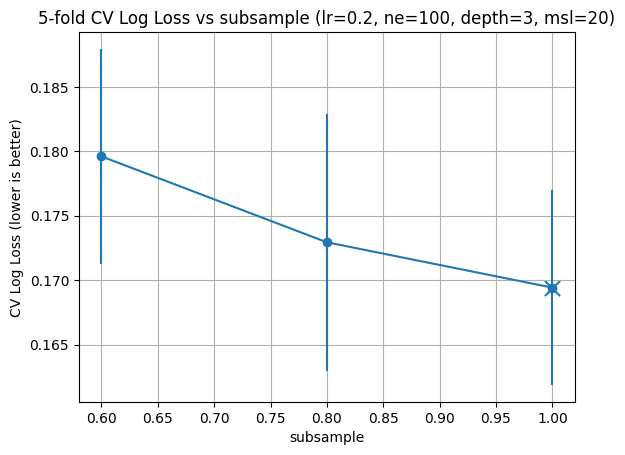

[RESULT] best subsample = 1.0 | CV log loss = 0.1694 (±0.0075)


In [45]:
# SUPPORT2: subsample sweep (lr=0.2, ne=100, depth=3, msl=20)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

#load & features
df = pd.read_csv("support2_imputed.csv", low_memory=False)
target = "hospdead" if "hospdead" in df.columns else "hosdead"
y = df[target].astype(int).values
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
#fixed params; sweep subsample
base = GradientBoostingClassifier(
    learning_rate=0.2, n_estimators=100, max_depth=3,
    min_samples_leaf=20, random_state=0
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

sub_grid = [0.6, 0.8, 1.0]
means, stds = [], []
for sub in sub_grid:
    mdl = base.set_params(subsample=sub)
    scores = cross_val_score(mdl, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
    means.append(-scores.mean())     # CV log loss (positive)
    stds.append(scores.std())

best_i = int(np.argmin(means))
best_sub, best_ll, best_std = sub_grid[best_i], means[best_i], stds[best_i]

plt.figure()
plt.plot(sub_grid, means, marker="o")
plt.errorbar(sub_grid, means, yerr=stds, fmt="none")
plt.scatter(best_sub, best_ll, marker="x", s=120)
plt.title("5-fold CV Log Loss vs subsample (lr=0.2, ne=100, depth=3, msl=20)")
plt.xlabel("subsample"); plt.ylabel("CV Log Loss (lower is better)")
plt.grid(True); plt.show()

print(f"[RESULT] best subsample = {best_sub} | CV log loss = {best_ll:.4f} (±{best_std:.4f})")

In [46]:
from sklearn.model_selection import cross_val_score

gb_final = base.set_params(subsample=best_sub)
ll  = cross_val_score(gb_final, X, y, scoring="neg_log_loss", cv=cv, n_jobs=-1)
f1  = cross_val_score(gb_final, X, y, scoring="f1_macro",   cv=cv, n_jobs=-1)

print(f"[FINAL] CV log loss={-ll.mean():.4f} (±{ll.std():.4f}) | "
      f"Macro-F1={f1.mean():.4f} (±{f1.std():.4f}) | "
      f"params: lr=0.2, n_estimators=100, max_depth=3, min_samples_leaf=20, subsample={best_sub}")

[FINAL] CV log loss=0.1694 (±0.0075) | Macro-F1=0.9048 (±0.0051) | params: lr=0.2, n_estimators=100, max_depth=3, min_samples_leaf=20, subsample=1.0


### SUPPORT2 Modeling Summary

The SUPPORT2 section extends gradient boosting tuning to a clinical classification task. The results provide another comparison point for how boosting performs across healthcare datasets with different structures and prediction targets.
